## Problem Statement
To develop a RAG based document question answering system that can answer user questions using information from documents and returns relevant answers based on the query.

## Setup Gemini API Key
Get your API KEY from [here](https://aistudio.google.com/app/api-keys) 

In [ ]:
import os
os.environ["GOOGLE_API_KEY"] = "PASTE_YOUR_KEY_HERE"

## Imports

In [ ]:
from IPython.display import Image, display, Markdown
from langchain_google_genai import ChatGoogleGenerativeAI
import base64
from langchain_community.document_loaders import UnstructuredPDFLoader
import htmltabletomd
from langchain_core.messages import HumanMessage
import uuid
from langchain_chroma import Chroma
from langchain_classic.schema.document import Document
from langchain_classic.storage import InMemoryStore
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
from langchain_google_genai import GoogleGenerativeAIEmbeddings

## Load and Extract the Data
Extract all the elements from the PDF. These elements can be tables, images, texts etc.

In [ ]:
file_path = "attention_paper.pdf"
loader = UnstructuredPDFLoader(file_path=file_path,
                               strategy='hi_res',
                               extract_images_in_pdf=True,
                               infer_table_structure=True,
                               chunking_strategy="by_title",
                               max_characters=10000,
                               new_after_n_chars=6000,
                               combine_text_under_n_chars=2000,
                               mode='elements',
                               image_output_dir_path='./figures')
data = loader.load()
len(data)

## Validation of Text, Image, and Table Extraction

In [ ]:
display(Markdown(data[5].metadata['text_as_html']))

<table><thead><tr><th>Layer Type</th><th>Complexity per Layer</th><th>Sequential Operations</th><th>Maximum Path Length</th></tr></thead><tbody><tr><td>Self-Attention</td><td>O(n? - d)</td><td>O(1)</td><td>O(1)</td></tr><tr><td>Recurrent</td><td>O(n- d?)</td><td>O(n)</td><td>O(n)</td></tr><tr><td>Convolutional</td><td>O(k-n-d?)</td><td>O(1)</td><td>O(logx.(n))</td></tr><tr><td>Self-Attention (restricted)</td><td>O(r-n-d)</td><td>oO(1)</td><td>O(n/r)</td></tr></tbody></table>

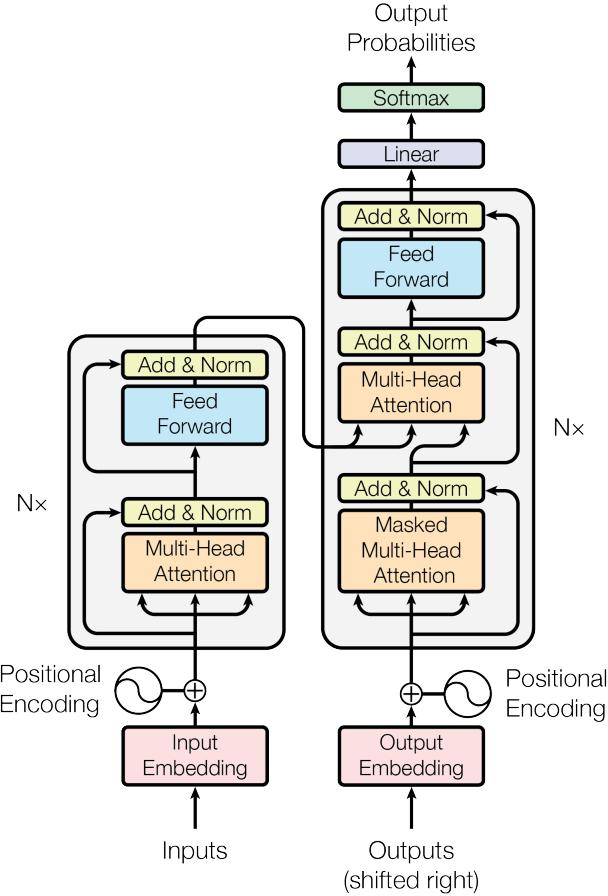

In [ ]:
display(Image(filename="figures/figure-3-1.jpg"))

## Seperate Text and Table Elements

In [ ]:
docs = []
tables = []

for doc in data:
    html_table = doc.metadata.get("text_as_html")

    if html_table:
        md_table = htmltabletomd.convert_table(html_table)
        tables.append(md_table)

    if doc.page_content:
        docs.append(doc.page_content)

## Generate Texts and Table Summaries

In [ ]:
prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additional comment.
Just give the summary as it is.
Table or text chunk: {element}

"""
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-pro",
    temperature=0,
    max_retries=2
)

def build_prompt(element):
    return f"""
You are an assistant tasked with summarizing tables and text.

Give a concise summary of the content.

Respond ONLY with the summary.

Content:
{element}
"""

def summarize(element):
    prompt = build_prompt(element)
    response = model.invoke(prompt)
    return response.content

text_summaries = []
table_summaries = []

for doc in docs:
    text_summaries.append(summarize(doc))

for table in tables:
    table_summaries.append(summarize(table))

In [ ]:
text_summaries[0]

'The paper "Attention Is All You Need" by Vaswani et al. introduces the Transformer, a novel network architecture for sequence transduction tasks that relies solely on attention mechanisms, completely avoiding recurrence and convolutions. This model is more parallelizable, requires significantly less training time, and achieves superior quality. On the WMT 2014 machine translation tasks, it set new state-of-the-art results, achieving a 28.4 BLEU score for English-to-German and 41.8 for English-to-French. The paper also demonstrates the Transformer\'s effectiveness on English constituency parsing.'

In [ ]:
table_summaries[0]

'The table compares four neural network layer types based on their computational properties. Self-Attention layers are highly parallelizable (O(1) sequential operations) and have the shortest path for long-range dependencies (O(1)), but suffer from high quadratic complexity (O(n²·d)). Recurrent layers are inherently sequential (O(n)) with the longest path length (O(n)), making them difficult to parallelize. Convolutional and restricted Self-Attention layers offer a compromise, balancing computational complexity against path length and parallelization capabilities.'

## Generate Image Summaries

In [ ]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

def summarize_image(img_base64, prompt):
    msg = model.invoke(
        [
            HumanMessage(
                content=[
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {"url":
                                     f"data:image/jpeg;base64,{img_base64}"},
                    },
                ]
            )
        ]
    )
    return msg.content

In [ ]:
def generate_img_summaries(path):

    # Store image summaries
    image_summaries = []
    image_paths = []
    images_base64 = []

    # Prompt
    prompt = """You are an assistant responsible for generating descriptive summaries of images for retrieval purposes.
              Keep in mind that images may include elements such as graphs, charts, or tables.
              These descriptions will be converted into embeddings and used to locate the original image
              for question answering tasks. Provide a detailed, information-rich description that is optimized
              for accurate retrieval. Avoid adding extra labels like “Summary:” and rewrite the
              wording with slight variation.
             """

    for img_file in sorted(os.listdir(path)):
        if img_file.endswith(".jpg"):
            img_path = os.path.join(path, img_file)
            base64_image = encode_image(img_path)
            image_summaries.append(summarize_image(base64_image, prompt))
            image_paths.append(img_path)
            images_base64.append(base64_image)
    return images_base64, image_paths, image_summaries

# Image summaries
IMG_PATH = 'figures'
images_base64, image_paths, image_summaries = generate_img_summaries(IMG_PATH)

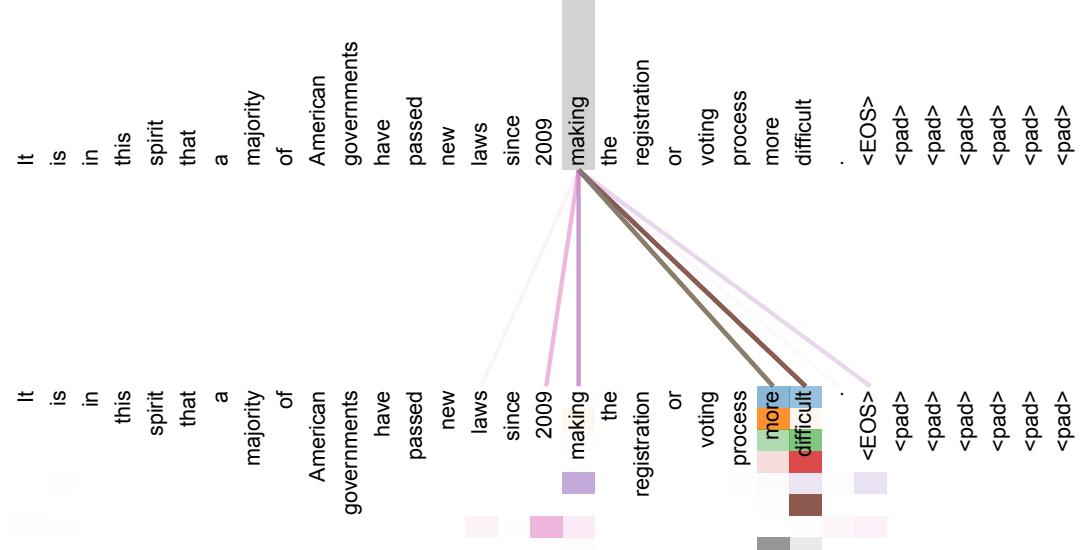

In [ ]:
display(Image(image_paths[0]))

In [ ]:
image_summaries[0]

'This is a visualization chart illustrating a concept in natural language processing, likely an attention mechanism. The graphic displays the same sentence twice, positioned one above the other. The sentence reads: "It is in this spirit that a majority of American governments have passed new laws since 2009 making the registration or voting process more difficult." The text is followed by special tokens, including `<EOS>` and `<pad>`.\n\nThe visualization highlights the relationships between words. Several colored lines, in shades of purple, brown, and green, originate from the word "making" in the lower sentence. These lines fan out and point to a set of words in the upper sentence, specifically "making", "the", "registration", "or", "voting", "process", "more", and "difficult".\n\nIn the top sentence, the word "making" is highlighted with a vertical gray bar. In the bottom sentence, the words "more" and "difficult" are highlighted with colored boxes, blue-green and red respectively. 

## Embed and Ingest to MultiVectorRetrieval Store

In [ ]:
def create_multi_vector_retriever(
    docstore, vectorstore, text_summaries, texts, table_summaries, tables,
    image_summaries, images
):
    """
    Create retriever that indexes summaries, but returns raw images or texts
    """
    id_key = "doc_id"

    # Create the multi-vector retriever
    retriever = MultiVectorRetriever(
        vectorstore=vectorstore,
        docstore=docstore,
        id_key=id_key,
    )

    # Helper function to add documents to the vectorstore and docstore
    def add_documents(retriever, doc_summaries, doc_contents):
        doc_ids = [str(uuid.uuid4()) for _ in doc_contents]
        summary_docs = [
            Document(page_content=s, metadata={id_key: doc_ids[i]})
            for i, s in enumerate(doc_summaries)
        ]
        retriever.vectorstore.add_documents(summary_docs)
        retriever.docstore.mset(list(zip(doc_ids, doc_contents)))

    if text_summaries:
        add_documents(retriever, text_summaries, texts)

    if table_summaries:
        add_documents(retriever, table_summaries, tables)

    if image_summaries:
        add_documents(retriever, image_summaries, images)
    return retriever

In [ ]:
  chroma_db = Chroma(
      collection_name="qa_rag",
      embedding_function=GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
  )

In [ ]:
docstore = InMemoryStore()
retriever_multi_vector = create_multi_vector_retriever(
    docstore,  chroma_db,
    text_summaries, docs,
    table_summaries, tables,
    image_summaries, images_base64,
)

## Check Retrieval

In [ ]:
# Retrieve
result_docs = retriever_multi_vector.invoke(
    "What is multi-head?"
)

In [ ]:
result_docs[0]

'3.2.2 Multi-Head Attention\n\nInstead of performing a single attention function with dmodel-dimensional keys, values and queries, we found it beneficial to linearly project the queries, keys and values h times with different, learned linear projections to dk, dk and dv dimensions, respectively. On each of these projected versions of queries, keys and values we then perform the attention function in parallel, yielding dv-dimensional\n\n‘To illustrate why the dot products get large, assume that the components of qg and k are independent random variables with mean 0 and variance 1. Then their dot product, g -k = ean qik;, has mean 0 and variance d,.\n\n4\n\noutput values. These are concatenated and once again projected, resulting in the final values, as depicted in Figure 2.\n\nMulti-head attention allows the model to jointly attend to information from different representation subspaces at different positions. With a single attention head, averaging inhibits this.\n\nMultiHead(Q,K,V ) = 

In [ ]:
def split_image_text_types(docs):
    images = []
    texts = []

    for doc in docs:
        content = doc.page_content if hasattr(doc, "page_content") else doc
        if isinstance(content, bytes):
            content = content.decode("utf-8")

        if isinstance(content, str) and content.startswith("/9j"):
            images.append(content)
        else:
            texts.append(content)

    return {"images": images, "texts": texts}

def plt_img_base64(img_base64):
    img_data = base64.b64decode(img_base64)
    img_buffer = BytesIO(img_data)
    img = Image.open(img_buffer)
    display(img)

def retrieve_context(query):
    docs = retriever_multi_vector.invoke(query)
    return split_image_text_types(docs)

def build_multimodal_prompt(question, context):
    text_context = "\n".join(context["texts"])

    content = []

    # text instruction
    content.append({
        "type": "text",
        "text": f"""
You are an expert analyst.

Question:
{question}

Context:
{text_context}

Answer the question using only the provided context.
Do not hallucinate.
"""
    })

    # images
    for img in context["images"]:
        content.append({
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{img}"
            }
        })

    return HumanMessage(content=content)

def generate_answer(question, context):
    prompt = build_multimodal_prompt(question, context)

    response = generation_model.invoke([prompt])

    return response.content

def multimodal_rag(query):
    context = retrieve_context(query)
    answer = generate_answer(query, context)

    return {
        "input": query,
        "context": context,
        "answer": answer
    }

In [ ]:
generation_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0, max_retries=2)

Based on the provided image, a transformer is an architecture composed of an encoder and a decoder, designed to process inputs and generate output probabilities.

The architecture looks like this:

**1. Encoder (Left Side):**
*   **Input Processing:** "Inputs" are first processed by an "Input Embedding" layer. "Positional Encoding" is then added to the embedded input.
*   **Encoder Layers:** This combined signal passes through a stack of "Nx" identical encoder layers. Each encoder layer consists of:
    *   A "Multi-Head Attention" block, followed by an "Add & Norm" layer.
    *   A "Feed Forward" block, followed by another "Add & Norm" layer.
    *   Skip connections are present around both the "Multi-Head Attention" and "Feed Forward" blocks, feeding into their respective "Add & Norm" layers.

**2. Decoder (Right Side):**
*   **Output Processing:** "Outputs (shifted right)" are processed by an "Output Embedding" layer. "Positional Encoding" is then added to the embedded output.
*   *

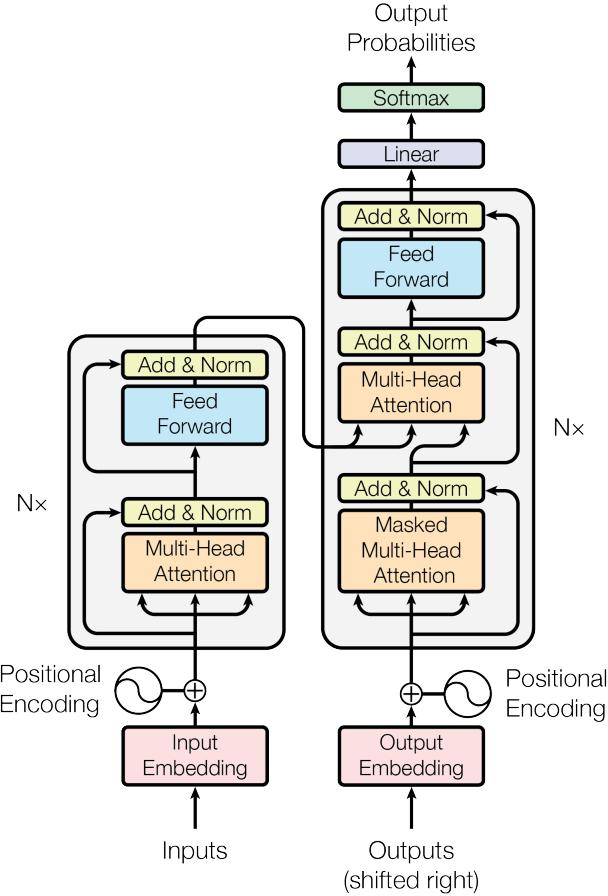

In [ ]:
result = multimodal_rag("What is transformer and how does the architecture look like?")

print(result["answer"])

images = result.get("context", {}).get("images", [])

if images:
    for img in images:
        plt_img_base64(img)

## Next Steps for Futher Improvement
1. Quantitative evaluation of different queries using the RAGAS framework
2. Controlling hallucinations by adding guardrails through post-generation validation, where guardrails are applied to the final output
3. Reducing the latency of the RAG system